中国儿童青少年视觉健康白皮书
https://report.iresearch.cn/report_pdf.aspx?id=4004

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

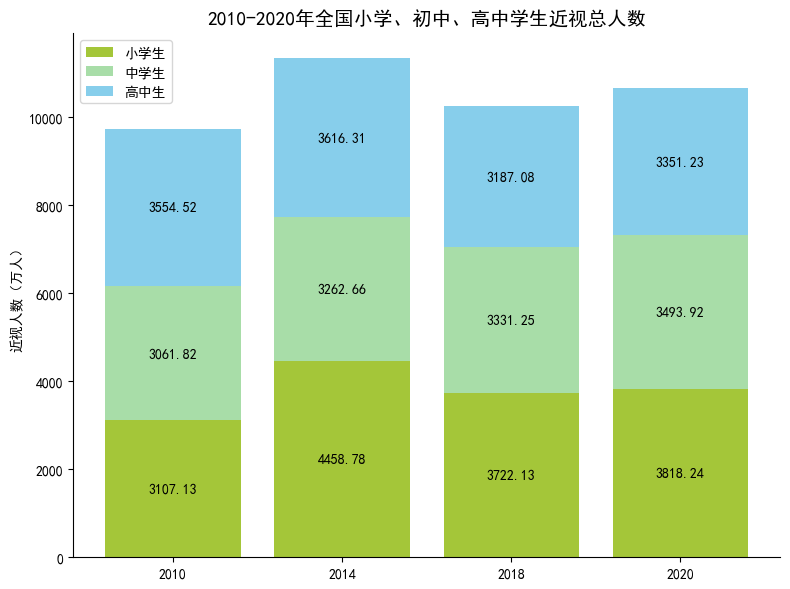

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = ["2010", "2014", "2018", "2020"]
# 各学段近视人数（万人），数据与图表对应层级一致，可按需微调
data = {
    "小学生": [3107.13, 4458.78, 3722.13, 3818.24],
    "中学生": [3061.82, 3262.66, 3331.25, 3493.92],
    "高中生": [3554.52, 3616.31, 3187.08, 3351.23]
}
# 颜色设置，匹配图表色调
colors = ["#A4C639", "#a8dda8", "#87CEEB"]  

# 创建画布
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制堆叠柱状图
bottom = np.zeros(len(years))
for i, (category, values) in enumerate(data.items()):
    ax.bar(years, values, bottom=bottom, color=colors[i], label=category)
    # 添加数据标注
    for x, y in zip(np.arange(len(years)), values):
        ax.text(x, bottom[x] + y / 2, f'{y}', ha='center', va='center', color='black')
    bottom += np.array(values)

# 设置y轴标签
ax.set_ylabel("近视人数（万人）")
# 设置标题
ax.set_title('2010-2020年全国小学、初中、高中学生近视总人数', fontsize=14, fontweight='bold')

# 添加图例
ax.legend()

# 美化：隐藏顶部、右侧边框
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

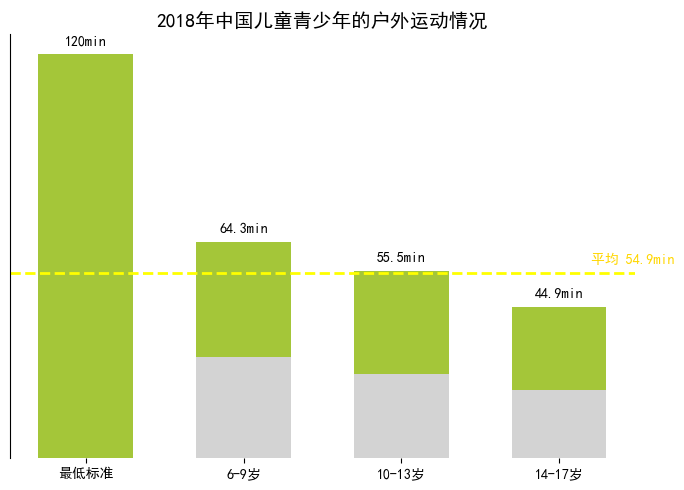

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 类别
categories = ["最低标准", "6-9岁", "10-13岁", "14-17岁"]
# 数据（min），与图表对应
data = [120, 64.3, 55.5, 44.9]
# 各类别中达到平均的部分（示意值，匹配图表视觉效果）
avg_parts = [120, 30, 25, 20]  
# 颜色设置
colors = ["#A4C639", "#D3D3D3", "#D3D3D3", "#D3D3D3"]  
avg_line_y = 54.9  # 平均时长

# 创建画布
fig, ax = plt.subplots(figsize=(7, 5))

# 绘制柱状图
x = np.arange(len(categories))
bar_width = 0.6
for i in range(len(categories)):
    # 绘制底部（灰色或绿色）
    rect = ax.bar(x[i], data[i], width=bar_width, color=colors[i])
    # 绘制顶部覆盖的“平均部分”（仅最低标准不需要覆盖，因为它本身就是绿色且超过平均）
    if categories[i] != "最低标准":
        ax.bar(x[i], data[i] - avg_parts[i], bottom=avg_parts[i], width=bar_width, color=colors[0])
    # 添加数据标注
    ax.text(x[i], data[i] + 2, f'{data[i]}min', ha='center', va='bottom', color='black')

# 绘制平均时长的黄色虚线
ax.axhline(y=avg_line_y, color='yellow', linestyle='--', linewidth=2)
ax.text(3.2, avg_line_y + 2, f'平均 {avg_line_y}min', ha='left', va='bottom', color='gold', fontweight='bold')

# 设置x轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(categories)
# 隐藏y轴刻度
ax.set_yticks([])
# 设置标题
ax.set_title('2018年中国儿童青少年的户外运动情况', fontsize=14, fontweight='bold')

# 美化：隐藏顶部、右侧和底部边框
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\86136\AppData\Local\Temp\ipykernel_26216\2478044944.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("autumn_r")  # 橙红色渐变


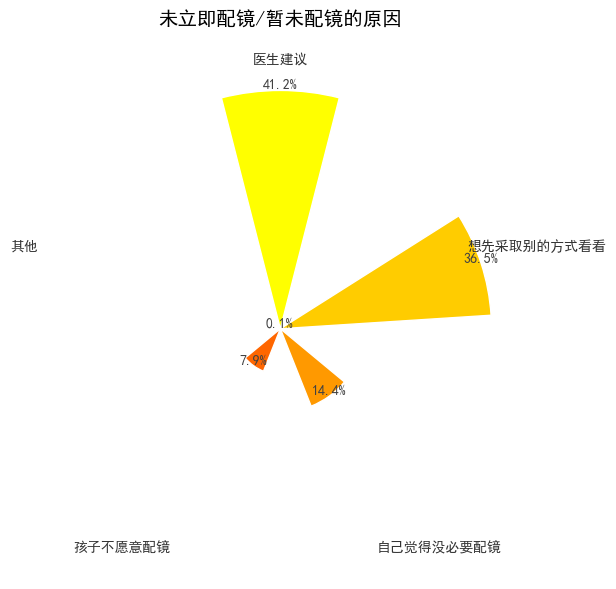

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# -------------------- 数据准备 --------------------
reasons = [
    "医生建议", "想先采取别的方式看看", 
    "自己觉得没必要配镜", "孩子不愿意配镜", "其他"
]
percentages = [41.2, 36.5, 14.4, 7.9, 0.1]

# 极坐标角度划分（每个分类一个角度）
angles = np.linspace(0, 2 * np.pi, len(reasons), endpoint=False)
# 将数据转为 numpy 数组
data = np.array(percentages)

# 设置颜色渐变
cmap = cm.get_cmap("autumn_r")  # 橙红色渐变
colors = [cmap(i / len(data)) for i in range(len(data))]

# -------------------- 创建极坐标图 --------------------
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

# 设置起始角度 & 排列方向
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 绘制极坐标柱状图
bars = ax.bar(angles, data, width=0.5, color=colors, edgecolor="white", linewidth=1)

# 添加数据标注
for i, (bar, percentage) in enumerate(zip(bars, data)):
    angle = angles[i]
    ax.text(
        angle, bar.get_height(),
        f"{percentage}%",
        ha='center', va='bottom',
        fontsize=10, fontweight="bold",
        color="#424242"
    )

# 添加标签（类别）
ax.set_xticks(angles)
ax.set_xticklabels(reasons, fontsize=10, color="#333333")

# 去除极轴线与刻度
ax.set_yticklabels([])
ax.spines["polar"].set_visible(False)
ax.grid(False)

# 添加标题
ax.set_title("未立即配镜/暂未配镜的原因", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()


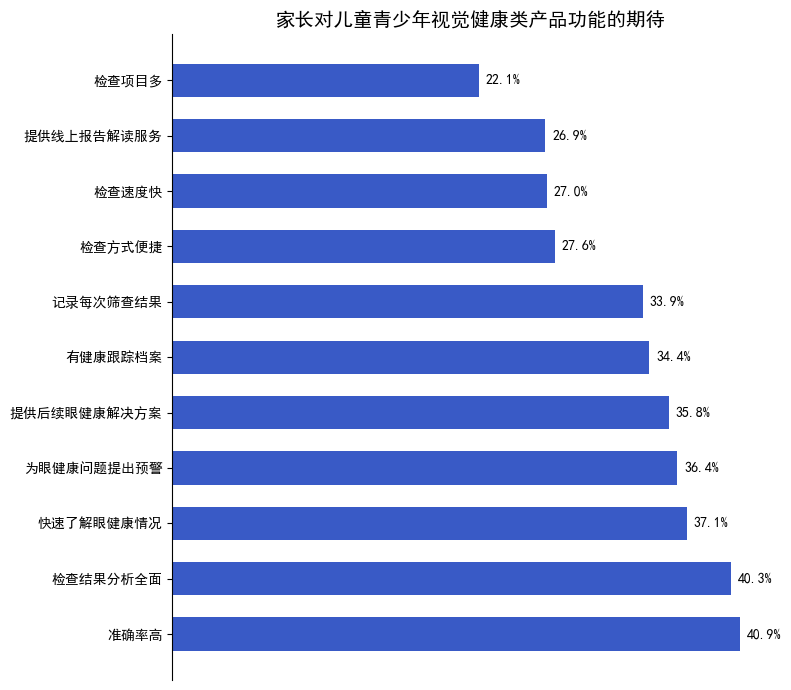

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 功能期待项
functions = [
    "准确率高",
    "检查结果分析全面",
    "快速了解眼健康情况",
    "为眼健康问题提出预警",
    "提供后续眼健康解决方案",
    "有健康跟踪档案",
    "记录每次筛查结果",
    "检查方式便捷",
    "检查速度快",
    "提供线上报告解读服务",
    "检查项目多"
]
# 对应占比（%），数据与图表一致
percentages = [40.9, 40.3, 37.1, 36.4, 35.8, 34.4, 33.9, 27.6, 27.0, 26.9, 22.1]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(8, 7))

# 绘制水平条形图
y = np.arange(len(functions))
bar_width = 0.6
bars = ax.barh(y, percentages, height=bar_width, color="#395AC6")

# 添加数据标注
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),  # 标注位置调整
                textcoords="offset points",
                ha='left', va='center')

# 设置y轴刻度和标签（调整顺序，让第一个功能在最上方）
ax.set_yticks(y)
ax.set_yticklabels(functions)
# 隐藏x轴刻度
ax.set_xticks([])
# 设置标题
ax.set_title("家长对儿童青少年视觉健康类产品功能的期待", fontsize=14, fontweight="bold")

# 美化图表，隐藏顶部、右侧和底部边框
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()  # 自动调整布局
plt.show()